# Downscaling Temperature at 2m for NYC **Tristate** area

**Variables:**
* Variable to be downscaled: Temperature at 2 meters (T2)
* Predictor variable: Surface Pressure (PSFC) 

**Dataset Resolutions:**
* uWRF (Domain 02): 3-hourly, 3 km
* NAM: 3-hourly, 12 km

**Spatial Coverage:**
* 115,291.16 km²

In [2]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import dl4d as dds
#import dl4ds as dds
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import models

2025-06-04 16:55:29.187585: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/compiler/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/libfabric/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib/release:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/ipp/lib/intel64:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mkl/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/tbb/lib/intel64/gcc4.8:/software1/intel/2020_update2/debugger_2020/python/intel64/lib:/software1/intel/2020_update2/deb

In [3]:
!python --version
#Should be Python 3.8.18

Python 3.7.12


In [5]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [6]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [7]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'



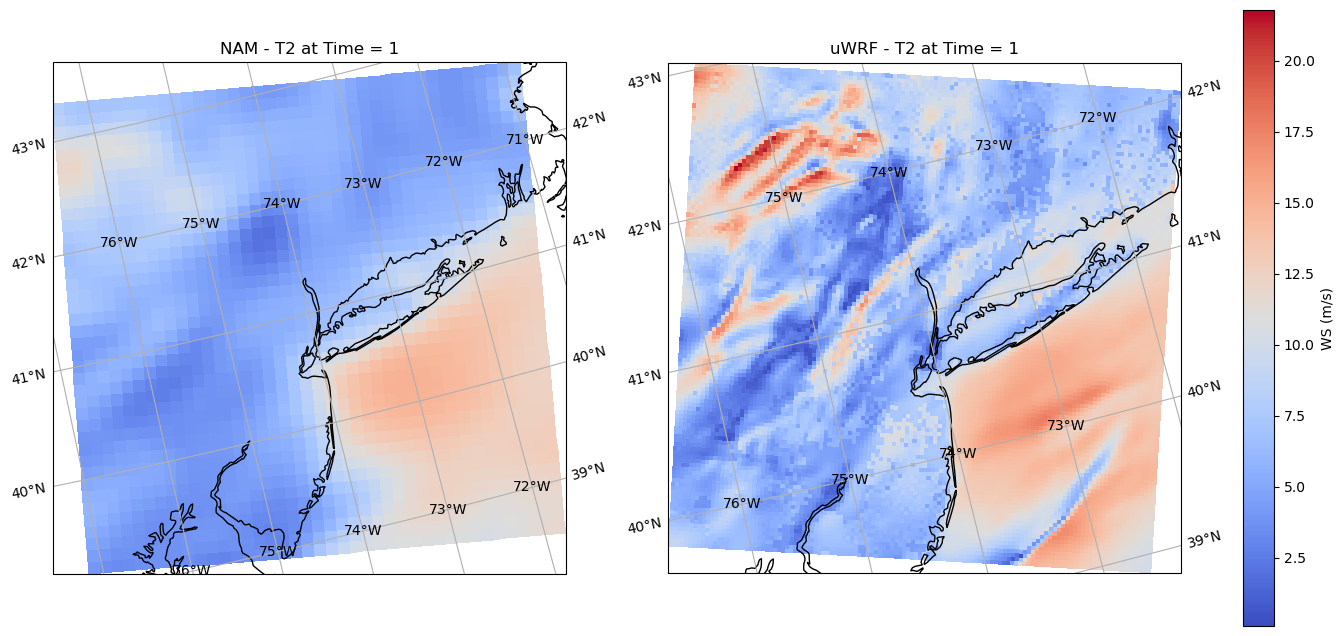

In [10]:
#comparing!
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

nam = nam_train.WS
uwrf = uwrf_train.WS
t_idx = 1


# Extract values
lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[t_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[t_idx,:,:].values

# Determine common color limits
vmin = min(t2_nam.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_uwrf.max())

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im1 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM - T2 at Time = {t_idx}')
axes[0].coastlines()
axes[0].gridlines(draw_labels=True)

# Plot uWRF
im2 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'uWRF - T2 at Time = {t_idx}')
axes[1].coastlines()
axes[1].gridlines(draw_labels=True)

# Add single colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('WS (m/s)')


plt.show()

In [11]:
#High resolution (uWRF) data
WS_hr_train = uwrf_train.WS
WS_hr_val = uwrf_val.WS
WS_hr_test = uwrf_test.WS

T2_hr_train = uwrf_train.T2
T2_hr_val = uwrf_val.T2
T2_hr_test = uwrf_test.T2

#--------------------------
#Low resolution (NAM) data
T2_lr_train = nam_train.T2
T2_lr_val = nam_val.T2
T2_lr_test = nam_test.T2

WS_lr_train = nam_train.WS
WS_lr_val = nam_val.WS
WS_lr_test = nam_test.WS

In [12]:
T2_scaler_train = dds.StandardScaler(axis=None)
T2_scaler_train.fit(T2_hr_train)  

WS_scaler_train = dds.StandardScaler(axis=None)
WS_scaler_train.fit(WS_hr_train)
#----------------------------------------------
#High resolution (uWRF):
y_z_train = T2_scaler_train.transform(T2_hr_train)
y_z_val = T2_scaler_train.transform(T2_hr_val)
y_z_test = T2_scaler_train.transform(T2_hr_test)


y_train = WS_scaler_train.transform(WS_hr_train)
y_val = WS_scaler_train.transform(WS_hr_val)
y_test = WS_scaler_train.transform(WS_hr_test)

#-------------------------------------------------
#Low resolution (NAM)

x_z_train = T2_scaler_train.transform(T2_lr_train)
x_z_val = T2_scaler_train.transform(T2_lr_val)
x_z_test = T2_scaler_train.transform(T2_lr_test)

x_train = WS_scaler_train.transform(WS_lr_train)
x_val = WS_scaler_train.transform(WS_lr_val)
x_test = WS_scaler_train.transform(WS_lr_test)

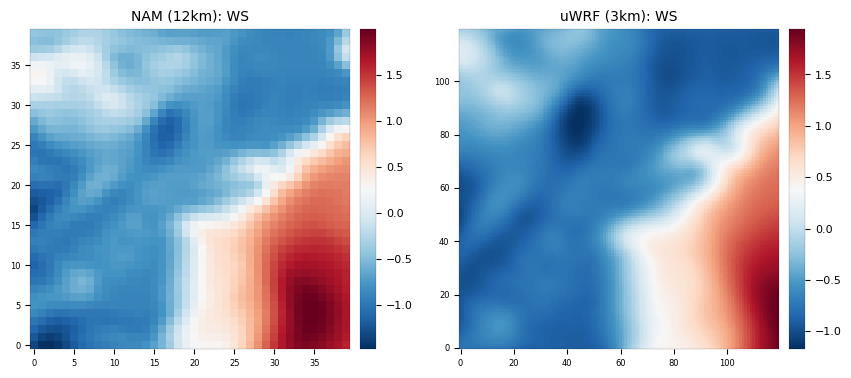

In [14]:
#WS: Wind Speed
ecv.plot((x_train[0].values, y_train[0]), subplot_titles=('NAM (12km): WS', 'uWRF (3km): WS'))

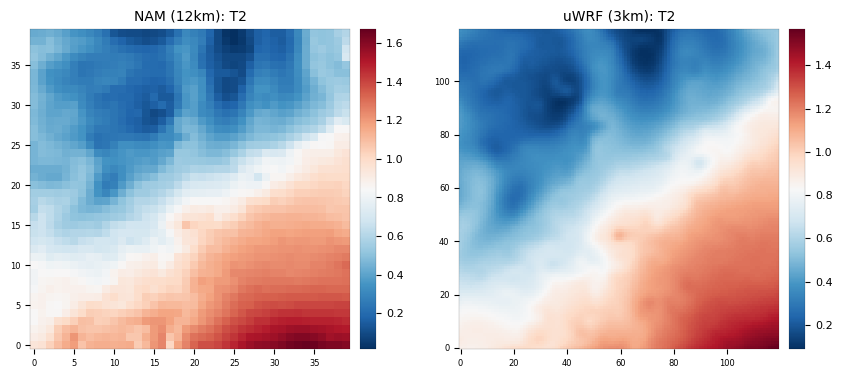

In [15]:
#T2: Temperature at 2m (K)
ecv.plot((x_z_train[0].values, y_z_train[0]), subplot_titles=('NAM (12km): T2', 'uWRF (3km): T2'))

In [16]:
y_train = y_train.expand_dims(dim='channel', axis=-1)
y_val = y_val.expand_dims(dim='channel', axis=-1)
y_test = y_test.expand_dims(dim='channel', axis=-1)

y_z_train = y_z_train.expand_dims(dim ='channel', axis=-1)
y_z_val = y_z_val.expand_dims(dim ='channel', axis=-1)
y_z_test = y_z_test.expand_dims(dim ='channel', axis=-1)

#-----------------------------------------------------

x_train = x_train.expand_dims(dim='channel', axis=-1)
x_val = x_val.expand_dims(dim='channel', axis=-1)
x_test = x_test.expand_dims(dim='channel', axis=-1)

x_z_train = x_z_train.expand_dims(dim ='channel', axis=-1)
x_z_val = x_z_val.expand_dims(dim ='channel', axis=-1)
x_z_test = x_z_test.expand_dims(dim ='channel', axis=-1)

In [17]:
print("T2 hr data shape:")
print(y_train.shape, y_val.shape, y_test.shape)
print("")
print("WS hr data shape:")
print(y_z_train.shape, y_z_val.shape, y_z_test.shape)
print("")
print("T2 lr data shape:")
print(x_train.shape, x_val.shape, x_test.shape)
print("")
print("WS lr data shape:")
print(x_z_train.shape, x_z_val.shape, x_z_test.shape)

T2 hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

WS hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

T2 lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

WS lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)


In [18]:
df = dds.create_pair_hr_lr(y_train.values[15], None, 'spc', 4, None, None, y_z_train.values[15], None, False, interpolation='inter_area')

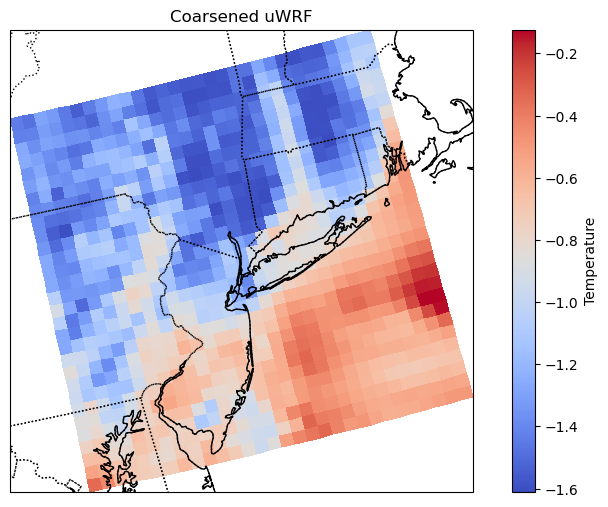

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract temperature data (1st or 2nd channel)
temp = df[1][:, :, 0]  # or df[1][:, :, 1] for the second

H, W = temp.shape
t_idx = 15
lat_vals = np.linspace(38.88588, 43.029186, H)
lon_vals = np.linspace(-76.70499, -71.21628, W)
lon, lat = np.meshgrid(lon_vals, lat_vals)


# Plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.LambertConformal()})
mesh = ax.pcolormesh(lon, lat, temp, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

plt.colorbar(mesh, ax=ax, orientation='vertical', label='Temperature')
ax.set_title('Coarsened uWRF')
plt.show()


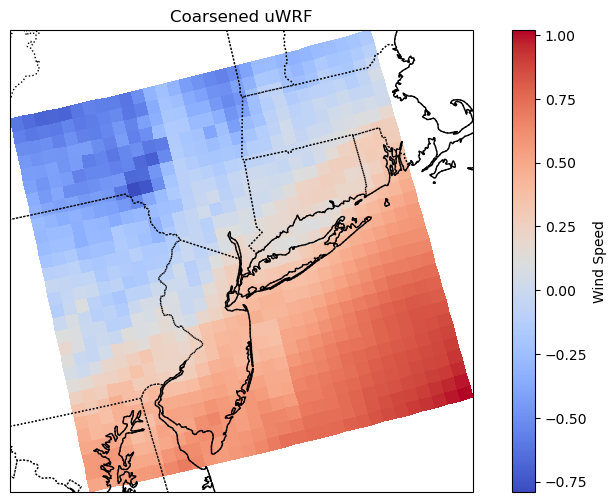

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Extract temperature data (1st or 2nd channel)
pres = df[1][:, :, 1]  # or df[1][:, :, 1] #channel 0 is temp, 1 is surface pressure

# Generate lat/lon assuming regular grid and known bounds
H, W = pres.shape
lat_vals = np.linspace(38.88588, 43.029186, H)
lon_vals = np.linspace(-76.70499, -71.21628, W)
lon, lat = np.meshgrid(lon_vals, lat_vals)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.LambertConformal()})
mesh = ax.pcolormesh(lon, lat, pres, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

plt.colorbar(mesh, ax=ax, orientation='vertical', label='Wind Speed')
ax.set_title('Coarsened uWRF')
plt.show()


In [ ]:
import os
import shutil
import csv
import pandas as pd

PSFC_train = [y_z_train]
PSFC_val = [y_z_val]
PSFC_test = [y_z_test]

#------------------------------------------------------------------------------------
results = []
best_loss = float('inf')
best_model_path = "/home/gvaillant1/downscaling/pretrained-models/T2-Best-Model" #**change**
other_models_path = "/home/gvaillant1/downscaling/pretrained-models/T2-Other-Models" #**change**
test_loss_file = os.path.join(other_models_path, "test_loss.txt")
runtime_file = os.path.join(other_models_path, "running_time.txt")
csv_file = "/home/gvaillant1/downscaling/results/T2_model_results.csv" #**change**
results = pd.read_csv(csv_file)
#------------------------------------------------------------------------------------
#TESTING DIFFERENT HYPER PARAMETERS:
#change the hyperparams to test different models
backbones = ['resnet']
num_filters = [8] 
num_blocks = [8]
epochs = [76]
lrate_values = (1e-3, 1e-4)
local_layer=True
#------------------------------------------------------------------------------------

#Check the existing results csv file to see if the parameter combination has already been tested
existing_results = []
if os.path.exists(csv_file):
    with open(csv_file, "r") as f:
        reader = csv.reader(f)
        next(reader, None)  # Skip header
        for row in reader:
            existing_results.append(tuple(row))

# Retrieve the lowest loss from CSV before training
if existing_results:
    best_loss = min(float(row[2]) for row in existing_results if row[2] != "NULL")

min_losses = {}

for backbone in backbones:
    for filters in num_filters:
        for blocks in num_blocks:
            for epoch in epochs:
                for lr in lrate_values:
                    ARCH_PARAMS = dict(n_filters=filters,
                                       n_blocks=blocks,
                                       normalization=None,
                                       dropout_rate=0.5,
                                       dropout_variant='spatial',
                                       attention=False,
                                       activation='relu',
                                       localcon_layer=local_layer)
        
                    print(f"Running model with backbone={backbone}, filters={filters}, blocks={blocks}, epochs={epoch}")
        
                    trainer = dds.SupervisedTrainer(
                        backbone=backbone,
                        upsampling='spc',
                        data_train=y_train,
                        data_val=y_val,
                        data_test=y_test,
                        data_train_lr=None,
                        data_val_lr=None,
                        data_test_lr=None,
                        scale=3,
                        time_window=None,
                        static_vars=None,
                        predictors_train=PSFC_train, #Add predictor information here (not required)
                        predictors_val=PSFC_val, #Add predictor information here (not required)
                        predictors_test=PSFC_test, #Add predictor informatio here (not required)
                        interpolation='inter_area',
                        patch_size=None,
                        batch_size=60,
                        loss='mae',
                        epochs=epoch,
                        steps_per_epoch=None,
                        validation_steps=None,
                        test_steps=None,
                        learning_rate=lr,
                        lr_decay_after=1e4,
                        early_stopping=False,
                        patience=6,
                        min_delta=0,
                        save=True,
                        save_bestmodel=True,
                        save_path=other_models_path,
                        show_plot=True,
                        verbose=True,
                        device='CPU',
                        **ARCH_PARAMS)
    
                # Create unique model identifier (ensure all fields match CSV format)
                #Needed to specify the datatypes so the code will be able to correctly check if we have done the model before
                model_id = (str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                            backbone, str(filters), str(blocks), str(lrate_values), trainer.interpolation, trainer.upsampling, 
                            str(trainer.epochs), trainer.loss, str(trainer.early_stopping), str(local_layer), str(trainer.device))
    
                model_id = (
                    str(y_train.name),
                    "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                    backbone,
                    str(filters),
                    str(blocks),
                    str(lrate_values),
                    trainer.interpolation,
                    trainer.upsampling,
                    str(trainer.epochs),
                    trainer.loss,
                    str(trainer.early_stopping),
                    str(local_layer),
                    str(trainer.device)
                )
    
                print(f"Checking if model has already been tested: {model_id}")
    
                #Check if model already exists in CSV
                model_exists = False
                for row in existing_results:
                    existing_model_id = (row[0], row[1], row[3], row[4], row[5], row[11], 
                                         row[9], row[8], row[6], row[12], row[13], row[16], row[17])
                    #print(f"Comparing with existing model: {existing_model_id}")
                    
                    if existing_model_id == model_id:
                        print("Match found! Skipping training for:", model_id)
                        model_exists = True
                        break
                
                if model_exists:
                    continue

                trainer.run()
    
                if os.path.exists(test_loss_file):
                    with open(test_loss_file, "r") as f:
                        val_loss = float(f.read().strip())
                else:
                    val_loss = float('inf')
    
                if os.path.exists(runtime_file):
                    with open(runtime_file, "r") as f:
                        training_runtime = f.read().strip()
                else:
                    training_runtime = "NULL"

                model_save_path = other_models_path  # Default save path

                #Check if the loss we just calculated is the lowest
                #If so, it is the best model and it should be put in the best model directory
                
                
                #Set the dictionary holding the lowest loss values.
                #This assumes that the results file has some data in it already
                for ele in results['Loss Function'].unique():
                    value = results.loc[results['Loss Function'] == ele, 'Test Loss'].values
                    min_losses[ele] = min(value)
                
                for key, value in min_losses.items():
                    if trainer.loss == key and val_loss < value:
                        min_losses[trainer.loss] = val_loss
                
                #print(min_losses)
                
                
                    # Remove previous best model completely before replacing it
                        if os.path.exists(best_model_path):
                            shutil.rmtree(best_model_path)  # Delete the entire directory
    
                        # Move new best model to the best model directory
                        shutil.move(other_models_path, best_model_path)
                        model_save_path = best_model_path #replace the model_save_path with the best model path if it has a lower loss
                        print('Moved to best model directory')

                    results = results.append(
                                pd.DataFrame([[
                                    str(y_train.name), 
                                    "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                    val_loss, 
                                    backbone, 
                                    filters, 
                                    blocks, 
                                    trainer.epochs, 
                                    trainer.model.count_params(), 
                                    trainer.upsampling, 
                                    trainer.interpolation, 
                                    trainer.batch_size, 
                                    lrate_values, 
                                    trainer.loss, 
                                    trainer.early_stopping, 
                                    training_runtime, 
                                    model_save_path, 
                                    local_layer, 
                                    trainer.device
                                ]], columns=["Downscaled Variable", "Predictor", "Test Loss",
                                             "Backbone", "Filters", "Blocks",
                                             "Epochs", "Parameters", "Upsampling Method",
                                             "Interpolation Method", "Batch Size", "Learning Rate",
                                             "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                            )



                #Write the information about the model and results in the results CSV file
                file_exists = os.path.isfile(csv_file)
                with open(csv_file, mode='a', newline='') as f:
                    writer = csv.writer(f)
                    if not file_exists:
                        writer.writerow(["Downscaled Variable", "Predictor", "Test Loss",
                                         "Backbone", "Filters", "Blocks",
                                        "Epochs", "Parameters", "Upsampling Method",
                                         "Interpolation Method", "Batch Size", "Learning Rate",
                                        "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                    writer.writerow([str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                     val_loss, backbone, filters, blocks,
                                     trainer.epochs, trainer.model.count_params(), trainer.upsampling,
                                     trainer.interpolation, trainer.batch_size, lrate_values, 
                                     trainer.loss, trainer.early_stopping, training_runtime, model_save_path, local_layer, trainer.device])
                
print("Training complete")

Running model with backbone=resnet, filters=8, blocks=8, epochs=76
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Running model with backbone=resnet, filters=8, blocks=8, epochs=76
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Checking if model has already been tested: ('WS', 'T2', 'resnet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', '76', 'mae', 'False', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-04 17:00:04
--------------------------------------------------------------------------------


2025-06-04 17:00:04.989741: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/gvaillant1/.conda/envs/dl4d/lib/python3.7/site-packages/cv2/../../lib64:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/compiler/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/libfabric/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib/release:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/ipp/lib/intel64:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mkl/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/tbb/lib/intel64/gcc4.8:/software1/intel/2020_up

Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 input_1 (InputLayer)                            [(None, 40, 40, 2)]              0                 []                                                
                                                                                                                                                      
 conv2d (Conv2D)                                 (None, 40, 40, 8)                152               ['input_1[0][0]']                                 
                                                                                                                                                      
 ResidualBlock1 (ResidualBlock)                  (None, 40, 40, 8)        

44/44 [==============================] - 107s 2s/step - loss: 0.6184 - val_loss: 0.2943
Epoch 2/76
44/44 [==============================] - ETA: 0s - loss: 0.3954

44/44 [==============================] - 98s 2s/step - loss: 0.3954 - val_loss: 0.2430
Epoch 3/76
44/44 [==============================] - ETA: 0s - loss: 0.3239

44/44 [==============================] - 98s 2s/step - loss: 0.3239 - val_loss: 0.2002
Epoch 4/76
44/44 [==============================] - ETA: 0s - loss: 0.2803

44/44 [==============================] - 97s 2s/step - loss: 0.2803 - val_loss: 0.1778
Epoch 5/76
44/44 [==============================] - ETA: 0s - loss: 0.2503

44/44 [==============================] - 98s 2s/step - loss: 0.2503 - val_loss: 0.1654
Epoch 6/76
44/44 [==============================] - ETA: 0s - loss: 0.2294

44/44 [==============================] - 97s 2s/step - loss: 0.2294 - val_loss: 0.1529
Epoch 7/76
 1/44 [..............................] - ETA: 54s - loss: 0.2288

# Inference on uWRF test Set

In [ ]:
pred = dds.Predictor(
    trainer, 
    y_test, 
    scale=3, 
    array_in_hr=True,
    static_vars=None, 
    predictors=[y_z_test], 
    time_window=None,
    interpolation='inter_area', 
    batch_size=64,
    scaler=T2_scaler_train,
    save_path=None,
    save_fname=None,
    return_lr=True,
    device='CPU')

unscaled_y_pred, coarsened_array = pred.run()

# Inference on NAM

In [ ]:
pred1 = dds.Predictor(
    trainer, 
    x_train, 
    scale=4, 
    array_in_hr=False,
    static_vars=None, 
    predictors=[x_z_train], 
    time_window=None,
    interpolation='inter_area', 
    batch_size=3,
    scaler=T2_scaler_train,
    save_path=None,
    save_fname=None,
    return_lr=True,
    device='CPU')

unscaled_x_pred, coarsened_array1 = pred1.run()

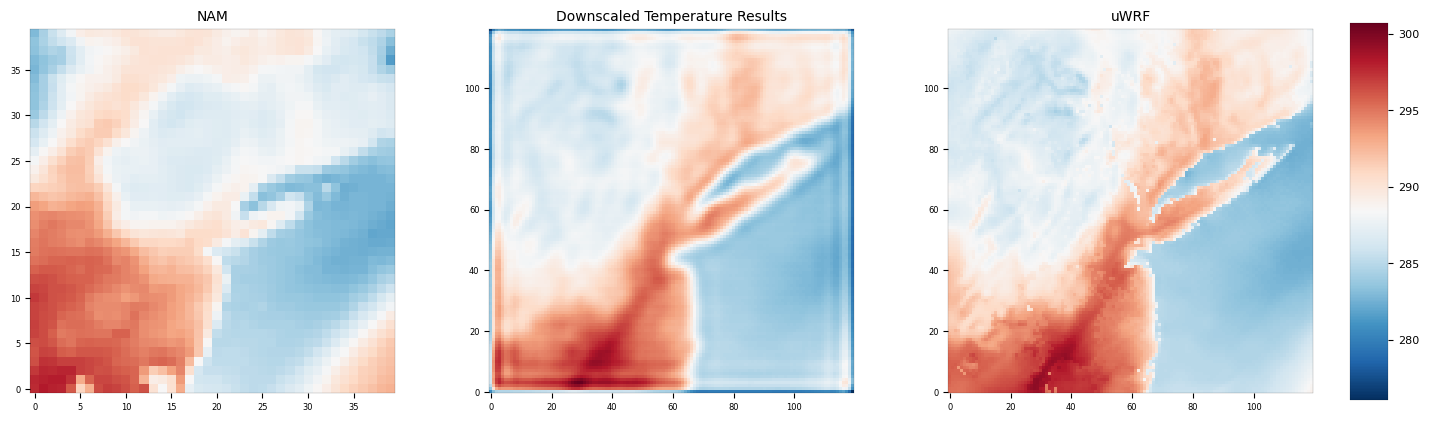

MAE for test set: 0.5977957248687744


In [19]:
unscaled_x_test = T2_scaler_train.inverse_transform(x_test)
unscaled_y_test = T2_scaler_train.inverse_transform(y_test)
ecv.plot((unscaled_x_test[0].values, unscaled_y_pred[0], unscaled_y_test[0].values),
         share_colorbar=True, share_dynamic_range=True, show_coastline=True, subplot_titles=('NAM', 'Downscaled Temperature Results', 'uWRF'))

mae = dds.losses.mae(unscaled_y_test[0].values, unscaled_y_pred[0])
print(f"MAE for test set: {mae}")

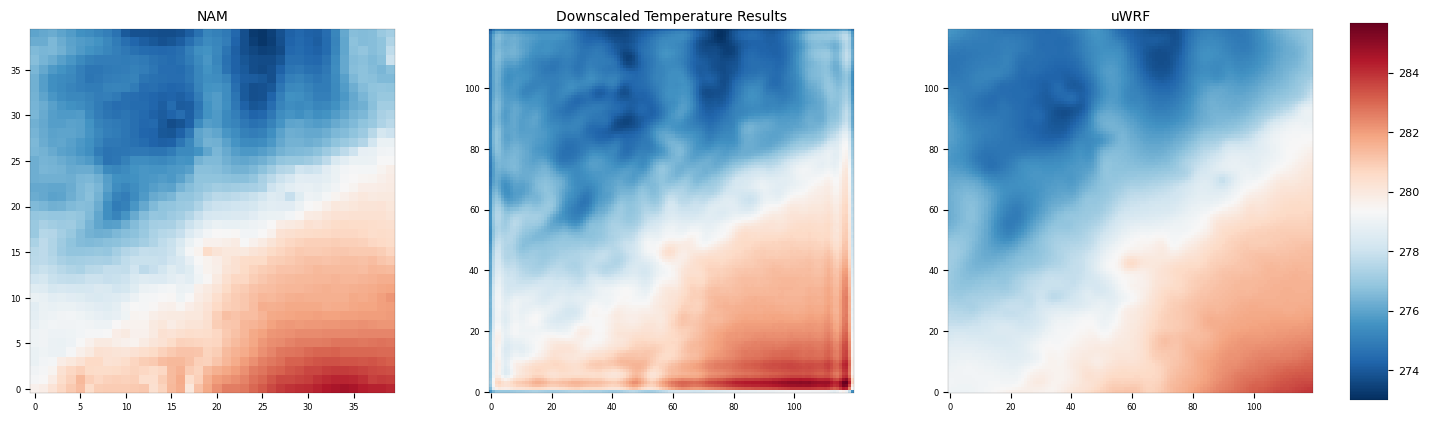

In [20]:
unscaled_x_train = T2_scaler_train.inverse_transform(x_train)
unscaled_y_train = T2_scaler_train.inverse_transform(y_train)
ecv.plot((unscaled_x_train[0].values, unscaled_x_pred[0], unscaled_y_train[0].values),
         share_colorbar=True, share_dynamic_range=True, subplot_titles=('NAM', 'Downscaled Temperature Results', 'uWRF'))

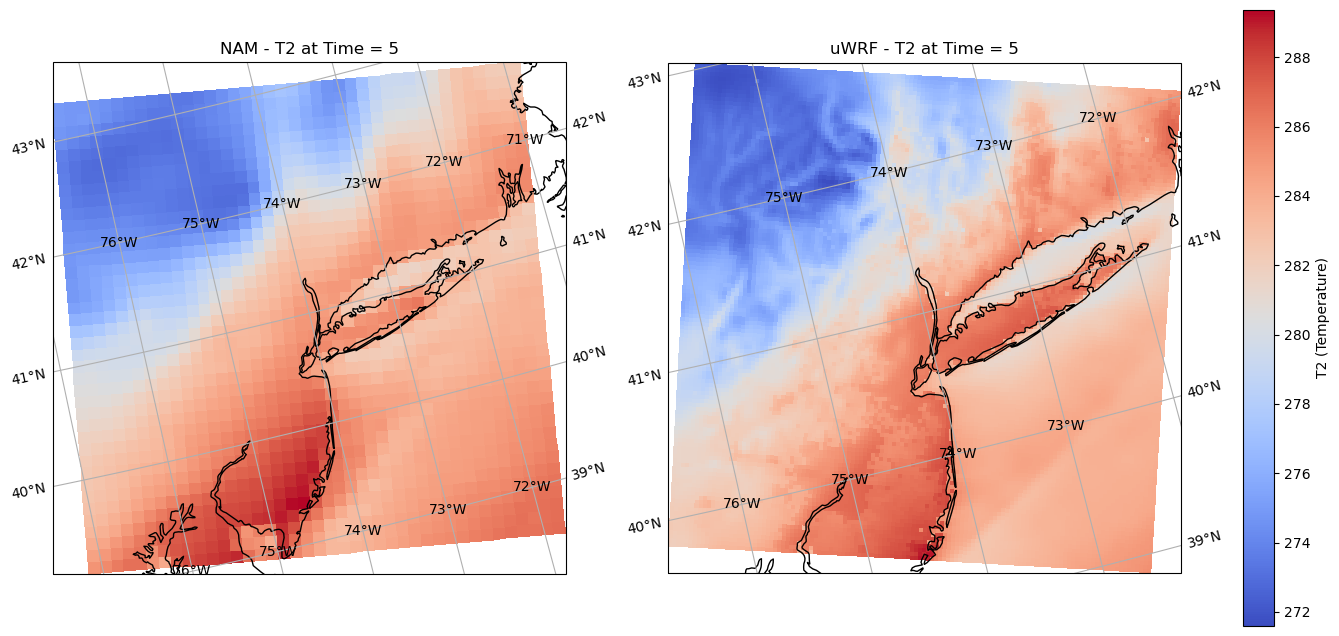

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr


nam = T2_lr_train
uwrf = T2_hr_train

t_idx = 5


# Extract values
lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[t_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[t_idx,:,:].values

# Determine common color limits
vmin = min(t2_nam.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_uwrf.max())

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im1 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM - T2 at Time = {t_idx}')
axes[0].coastlines()
axes[0].gridlines(draw_labels=True)

# Plot uWRF
im2 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'uWRF - T2 at Time = {t_idx}')
axes[1].coastlines()
axes[1].gridlines(draw_labels=True)

# Add single colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('T2 (Temperature)')


plt.show()


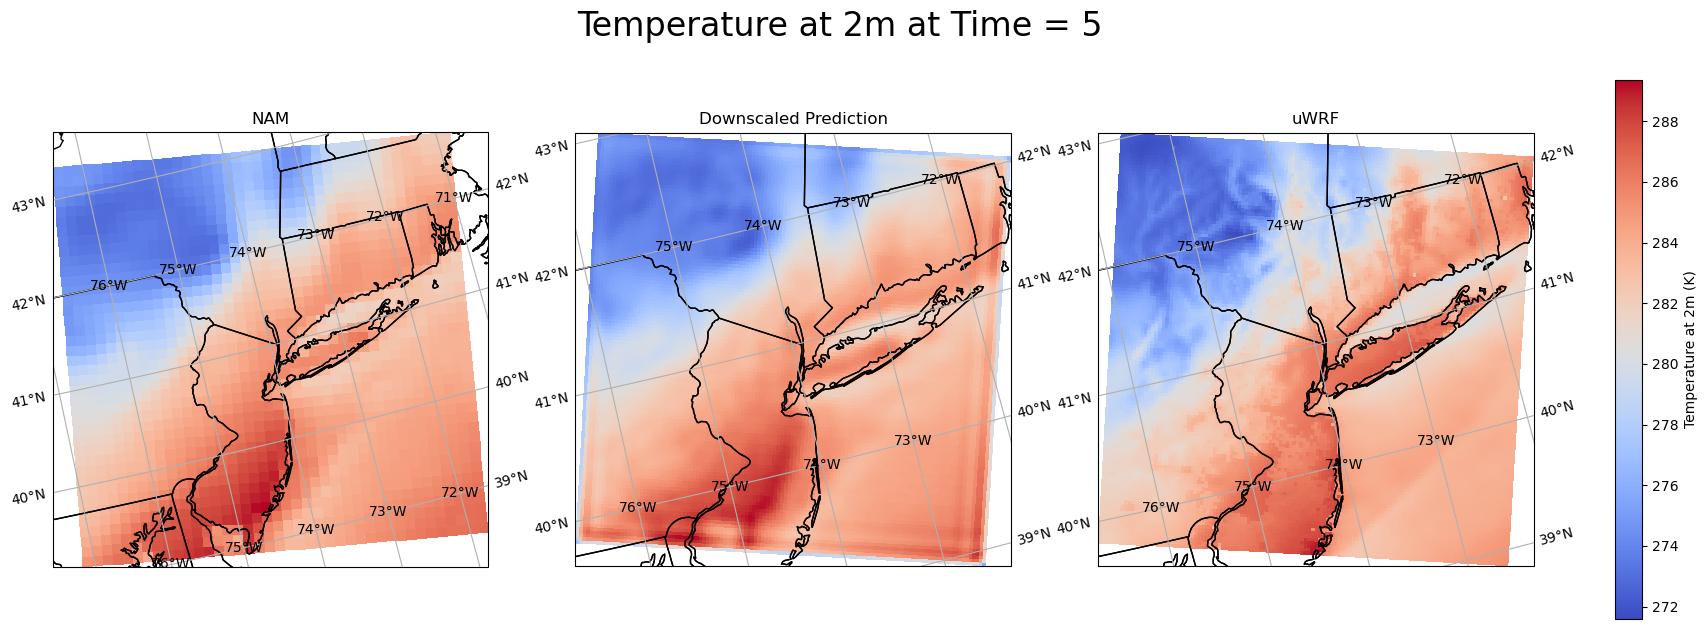

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

# Extract data
nam = unscaled_x_train  # NAM
results = unscaled_x_pred  # Predicted output (numpy array)
uwrf = unscaled_y_train  # uWRF (truth)


# Select time index
time_idx = 5 # CHANGE

lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[time_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[time_idx,:,:].values

# Prediction values — want to be the same resolution as uWRF
t2_pred = results[time_idx, :, :]

# Determine common color limits
vmin = min(t2_nam.min(), t2_pred.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_pred.max(), t2_uwrf.max())


fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im0 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM')
axes[0].coastlines()
axes[0].gridlines(draw_labels=True)
axes[0].add_feature(cfeature.STATES)

# Plot Prediction
im1 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, t2_pred, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'Downscaled Prediction')
axes[1].coastlines()
axes[1].gridlines(draw_labels=True)
axes[1].add_feature(cfeature.STATES)

# Plot uWRF
im2 = axes[2].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[2].set_title(f'uWRF')
axes[2].coastlines()
axes[2].gridlines(draw_labels=True)
axes[2].add_feature(cfeature.STATES)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Temperature at 2m (K)')

# Add main title
fig.suptitle(f'Temperature at 2m at Time = {time_idx}', fontsize=24)


plt.show()

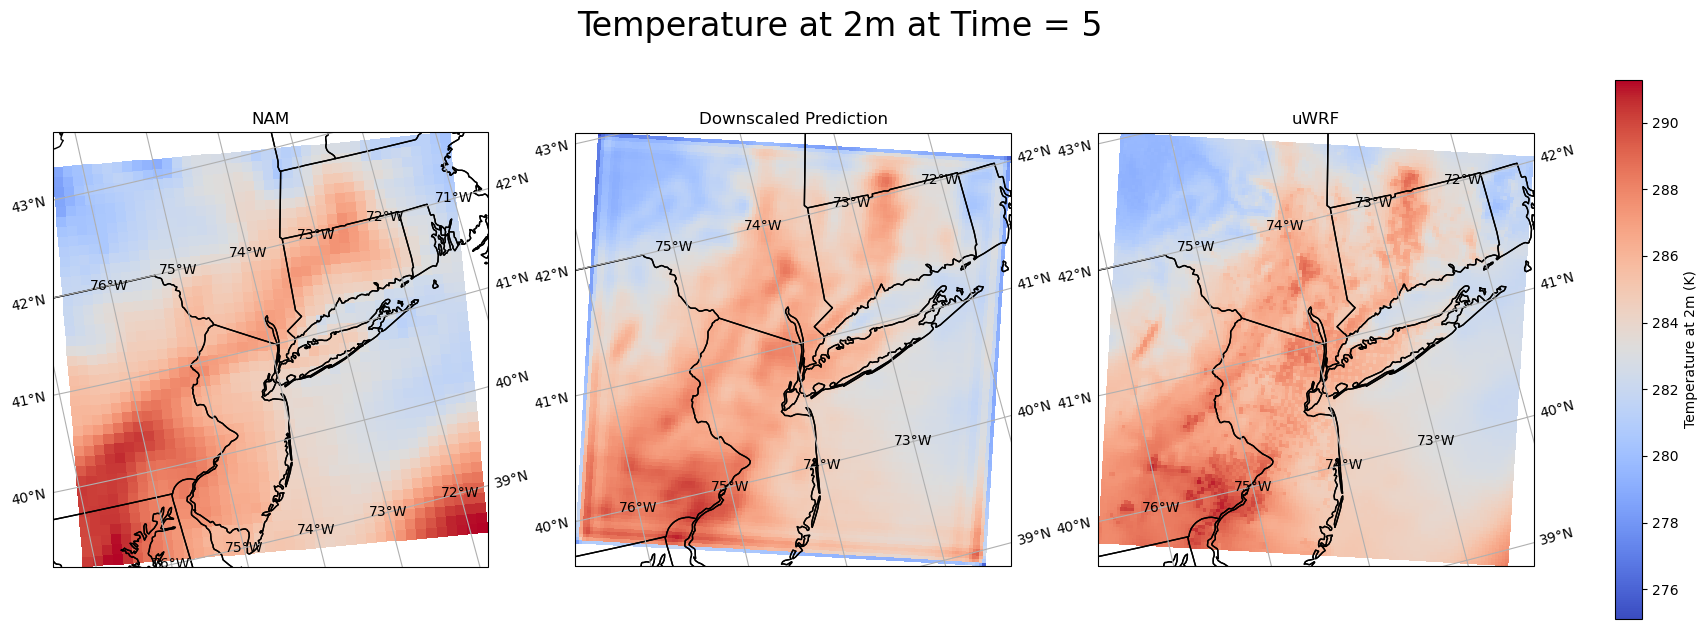

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

# Extract data
nam = unscaled_x_test  # NAM
results = unscaled_y_pred  # Predicted output (numpy array)
uwrf = unscaled_y_test  # uWRF (truth)


# Select time index
time_idx = 5 # CHANGE

lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[time_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[time_idx,:,:].values

# Prediction values — want to be the same resolution as uWRF
t2_pred = results[time_idx, :, :]

# Determine common color limits
vmin = min(t2_nam.min(), t2_pred.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_pred.max(), t2_uwrf.max())


fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im0 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM')
axes[0].coastlines()
axes[0].gridlines(draw_labels=True)
axes[0].add_feature(cfeature.STATES)

# Plot Prediction
im1 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, t2_pred, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'Downscaled Prediction')
axes[1].coastlines()
axes[1].gridlines(draw_labels=True)
axes[1].add_feature(cfeature.STATES)

# Plot uWRF
im2 = axes[2].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[2].set_title(f'uWRF')
axes[2].coastlines()
axes[2].gridlines(draw_labels=True)
axes[2].add_feature(cfeature.STATES)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Temperature at 2m (K)')

# Add main title
fig.suptitle(f'Temperature at 2m at Time = {time_idx}', fontsize=24)


plt.show()

In [43]:
import xarray as xr
import numpy as np

uwrf = xr.open_dataset("/D4/data/gvaillant/uwrf-split/uwrf_test.nc")


lat = uwrf["latitude"].isel(time=0).values  # shape (120, 120)
lon = uwrf["longitude"].isel(time=0).values  # shape (120, 120)
time = uwrf["time"].values[:578]  # shape (578,) — match time length of results


ds = xr.Dataset(
    {
        "T2_downscaled": (["time", "y", "x"], results)
    },
    coords={
        "time": ("time", time),
        "lat": (["y", "x"], lat),
        "lon": (["y", "x"], lon),
    }
)


ds["T2_downscaled"].attrs["units"] = "K"
ds["T2_downscaled"].attrs["long_name"] = "Downscaled 2-meter Temperature"


output_path = "/home/gvaillant1/T2_downscaled_output.nc"
ds.to_netcdf(output_path)

In [44]:
data = xr.open_dataset('/home/gvaillant1/T2_downscaled_output.nc')

data

<xarray.Dataset>
Dimensions:        (time: 578, y: 120, x: 120)
Coordinates:
  * time           (time) datetime64[ns] 2019-05-04T21:00:00 ... 2019-05-29T1...
    lat            (y, x) float32 ...
    lon            (y, x) float32 ...
Dimensions without coordinates: y, x
Data variables:
    T2_downscaled  (time, y, x) float32 ...